# 98 - DCGAN on Fashion-MNIST

**Section:** GANs | **Prereqs:** `GANs/CodeChallenge_Guassians_with_fewer_layers.ipynb` | **Next:** `GANs/CNN_GANs_CIFAR-10.ipynb`

The convolutional GAN on real images. Compare the output directly with
`GANs/Linear_GANs_FMNIST.ipynb` - same data, same task, convolutional generator:
the results are visibly sharper, with texture instead of blur.

**The 28x28 awkwardness.** DCGAN was designed for power-of-two sizes, and 28 is
not one. The generator handles it with a `kernel=3, stride=2, padding=1` layer to
go 4 -> 7, then standard `kernel=4, stride=2` layers for 7 -> 14 -> 28. Odd sizes
always need one hand-tuned layer like this.

**A DataLoader appears here** (unlike the linear GANs, which sampled random
indices), with dummy labels so the standard `for x, _ in loader` pattern works.
`drop_last=True` matters: several tensors are built with a hardcoded `bs`, and a
short final batch would raise a shape error.

**What to expect:** recognisable garments with plausible texture after enough
epochs, though the epoch count here (`15000/bs` = 117) is modest for a GAN. If the
output is still noisy, it needs more training, not a different architecture.

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchsummary
import sys

In [252]:
fmnist = torchvision.datasets.FashionMNIST(root='/', train=True, download=True)

In [253]:
fmnist.data.min(), fmnist.data.max()

(tensor(0, dtype=torch.uint8), tensor(255, dtype=torch.uint8))

In [254]:
# Scale to [-1,1] to match the generator's Tanh output.
data = fmnist.data

data = (data - data.min()) / (data.max() - data.min())
data = 2*data - data.max()

In [255]:
data.min(), data.max()

(tensor(-1.), tensor(1.))

In [256]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [257]:
# A DataLoader this time, with dummy labels so `for x, _ in loader` works.
# .unsqueeze(1) adds the channel axis: (N,28,28) -> (N,1,28,28).
# drop_last=True is required, not cosmetic - several tensors below are built with
# a hardcoded bs, and a short final batch would raise.
data  = data.float().to(device)
labels = torch.zeros(len(data)) # Adding dummy labels, will just acess like for x,_ in trainloader:

dataset = TensorDataset(data.unsqueeze(1),labels)

bs = 128
train_loader = DataLoader(dataset, batch_size=bs, shuffle=True,drop_last=True)

In [258]:
a,b = next(iter(train_loader))
a.shape

torch.Size([128, 1, 28, 28])

## Defining the models

In [259]:
# The discriminator: 28 -> 14 -> 7 -> 3 -> 1 via stride-2 convolutions, then a
# 1x1 convolution to project to a single value.
# The DCGAN architecture rules, from the 2015 paper, and they are worth
# following exactly - GANs are fragile and these were found empirically:
#   - stride-2 convolutions instead of pooling (both directions),
#   - BatchNorm everywhere except the generator's output and the
#     discriminator's input layer,
#   - ReLU in the generator, LeakyReLU(0.2) in the discriminator,
#   - Tanh on the generator's output, matching data normalised to [-1,1],
#   - bias=False on any conv followed by BatchNorm (its shift replaces the bias),
#   - Adam with lr=2e-4 and betas=(0.5, 0.999) - the low beta1 matters, since
#     the usual 0.9 keeps too much momentum from a non-stationary objective.
class discriminator(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,   64, 4, 2, 1, bias=False)   # 28 -> 14
    self.conv2 = nn.Conv2d(64,  128, 4, 2, 1, bias=False)  # 14 -> 7
    self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)  # 7  -> 3
    self.conv4 = nn.Conv2d(256, 512, 4, 2, 1, bias=False)  # 3  -> 1
    self.conv5 = nn.Conv2d(512, 1,   1, 1, 0, bias=False)  # 1x1 projection

    self.bn2 = nn.BatchNorm2d(128)
    self.bn3 = nn.BatchNorm2d(256)
    self.bn4 = nn.BatchNorm2d(512)

  def forward(self, x):
    x = F.leaky_relu(self.conv1(x), 0.2)
    x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
    x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
    x = F.leaky_relu(self.bn4(self.conv4(x)), 0.2)
    x = torch.sigmoid(self.conv5(x)).flatten(1)
    return x

In [260]:
dnet = discriminator().to(device)
dnet

discriminator(
  (conv1): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv3): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv4): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv5): Conv2d(512, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [261]:
torchsummary.summary(dnet,(1,28,28),batch_size=10)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [10, 64, 14, 14]           1,024
            Conv2d-2            [10, 128, 7, 7]         131,072
       BatchNorm2d-3            [10, 128, 7, 7]             256
            Conv2d-4            [10, 256, 3, 3]         524,288
       BatchNorm2d-5            [10, 256, 3, 3]             512
            Conv2d-6            [10, 512, 1, 1]       2,097,152
       BatchNorm2d-7            [10, 512, 1, 1]           1,024
            Conv2d-8              [10, 1, 1, 1]             512
Total params: 2,755,840
Trainable params: 2,755,840
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 2.34
Params size (MB): 10.51
Estimated Total Size (MB): 12.89
----------------------------------------------------------------


In [262]:
dnet(torch.randn((10,1,28,28)).to(device)).shape

torch.Size([10, 1])

In [263]:
# The generator, mirroring it: (100,1,1) -> 4 -> 7 -> 14 -> 28.
# Note deconv2 uses kernel=3, stride=2, padding=1 to get 4 -> 7. Standard
# kernel=4/stride=2 would give 8, and 28 is not a power of two - odd sizes always
# need one hand-tuned layer like this.
class generator(nn.Module):
    def __init__(self, latent_dim: int = 100):
        super().__init__()

        # 1 -> 4
        self.deconv1 = nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False)
        # 4 -> 7
        self.deconv2 = nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False)
        # 7 -> 14
        self.deconv3 = nn.ConvTranspose2d(128,  64, 4, 2, 1, bias=False)
        # 14 -> 28
        self.deconv4 = nn.ConvTranspose2d(64,    1, 4, 2, 1, bias=False)

        self.bn1 = nn.BatchNorm2d(256)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = F.relu(self.bn3(self.deconv3(x)))
        x = torch.tanh(self.deconv4(x))
        return x

torch.Size([10, 1, 28, 28])


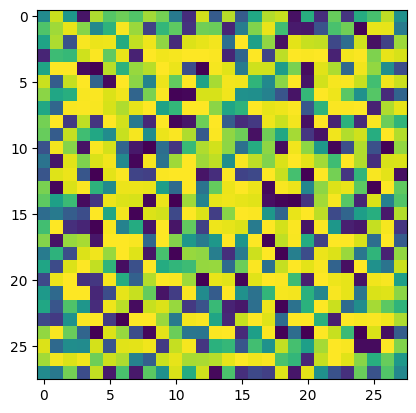

In [264]:
# Generating from (10,100,1,1) noise before training, to verify the output shape
# is (10,1,28,28) before committing to a long run.
gnet = generator().to(device)

y = gnet(torch.randn(10,100,1,1).to(device))
print(y.shape)
plt.imshow(y[0].squeeze().detach().cpu().numpy());

In [265]:
dnet(y).shape

torch.Size([10, 1])

In [266]:
# DCGAN optimizer settings: lr=1e-4, betas=(0.5,0.999).
# epochs = 15000/bs = 117 - modest for a GAN. If the samples still look noisy,
# the fix is more epochs, not a different architecture.
lossfunc = nn.BCELoss()

epochs = int(15000/bs)

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=.0001, betas=(.5,.999))
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=.0001, betas=(.5,.999))

In [267]:
bs

128

In [268]:
# THE GAN TRAINING LOOP. Two models, two optimizers, one alternating step:
#
# 1. DISCRIMINATOR: show it real images labelled 1 and fake images labelled 0,
#    and minimise BCE on both. It learns to tell them apart.
# 2. GENERATOR: make fresh fakes, run them through the discriminator, and
#    minimise BCE against label 1 - i.e. train the generator to make the
#    discriminator say 'real'.
#
# The label flip in step 2 is the whole trick: the generator has no direct
# target image, only the discriminator's opinion, so 'be more convincing' is
# expressed as 'make D output 1'.
#
# Fakes are REGENERATED between the two steps. Reusing the step-1 fakes would
# backpropagate through a stale graph, and torch would raise.
#
# What to watch: d_loss and g_loss should stay in tension. If d_loss collapses
# to 0 the discriminator won and the generator gets no useful gradient; if
# g_loss collapses the generator found a blind spot. Neither loss going to zero
# is success - equilibrium is.
#
# Batched over a DataLoader here rather than random index sampling, so this is
# one pass over the whole dataset per epoch.
losses = []
dnet_decisions = []

for epoch in range(epochs):

  batch_loss = torch.zeros((1,2))
  batch_dnet = torch.zeros((1,2))

  for x,_ in train_loader:
    real_images = x.to(device)
    fake_images = gnet( torch.randn((bs,100,1,1)).to(device) )

    real_labels = torch.ones((bs,1),device=device)
    fake_labels = torch.zeros((bs,1), device=device)

    # Training the discriminator
    pred_real = dnet(real_images)
    d_loss_real = lossfunc(pred_real, real_labels)

    pred_fake = dnet(fake_images)
    d_loss_fake = lossfunc(pred_fake, fake_labels)

    d_loss = d_loss_real + d_loss_fake

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    batch_loss[0,0] += d_loss.item()
    batch_dnet[0,0] += torch.mean((pred_real > 0.5).float()).detach().cpu().item()

    # Training the generator
    fake_images = gnet(torch.randn((bs,100,1,1)).to(device))
    fake_preds = dnet(fake_images)

    g_loss = lossfunc(fake_preds, real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    batch_loss[0,1] += g_loss.item()
    batch_dnet[0,1] += torch.mean((fake_preds > 0.5).float()).detach().cpu().item()

  # Saving once per epoch with correct indices
  losses.append([batch_loss[0,0].item(), batch_loss[0,1].item()])
  # batch_dnet[0,0] is real, batch_dnet[0,1] is fake
  dnet_decisions.append([batch_dnet[0,0].item(), batch_dnet[0,1].item()])

  msg = f'Epoch {epoch+1}/{epochs}'
  print(msg)

Epoch 1/117
Epoch 2/117
Epoch 3/117
Epoch 4/117
Epoch 5/117
Epoch 6/117
Epoch 7/117
Epoch 8/117
Epoch 9/117
Epoch 10/117
Epoch 11/117
Epoch 12/117
Epoch 13/117
Epoch 14/117
Epoch 15/117
Epoch 16/117
Epoch 17/117
Epoch 18/117
Epoch 19/117
Epoch 20/117
Epoch 21/117
Epoch 22/117
Epoch 23/117
Epoch 24/117
Epoch 25/117
Epoch 26/117
Epoch 27/117
Epoch 28/117
Epoch 29/117
Epoch 30/117
Epoch 31/117
Epoch 32/117
Epoch 33/117
Epoch 34/117
Epoch 35/117
Epoch 36/117
Epoch 37/117
Epoch 38/117
Epoch 39/117
Epoch 40/117
Epoch 41/117
Epoch 42/117
Epoch 43/117
Epoch 44/117
Epoch 45/117
Epoch 46/117
Epoch 47/117
Epoch 48/117
Epoch 49/117
Epoch 50/117
Epoch 51/117
Epoch 52/117
Epoch 53/117
Epoch 54/117
Epoch 55/117
Epoch 56/117
Epoch 57/117
Epoch 58/117
Epoch 59/117
Epoch 60/117
Epoch 61/117
Epoch 62/117
Epoch 63/117
Epoch 64/117
Epoch 65/117
Epoch 66/117
Epoch 67/117
Epoch 68/117
Epoch 69/117
Epoch 70/117
Epoch 71/117
Epoch 72/117
Epoch 73/117
Epoch 74/117
Epoch 75/117
Epoch 76/117
Epoch 77/117
Epoch 78

In [269]:
real_labels.shape , pred_real.shape

(torch.Size([128, 1]), torch.Size([128, 1]))

In [270]:
dnet(real_images).shape

torch.Size([128, 1])

In [271]:
real_images.shape

torch.Size([128, 1, 28, 28])

In [272]:
def smooth(x,k=15):
  return np.convolve(x,np.ones(k)/k,mode='same')

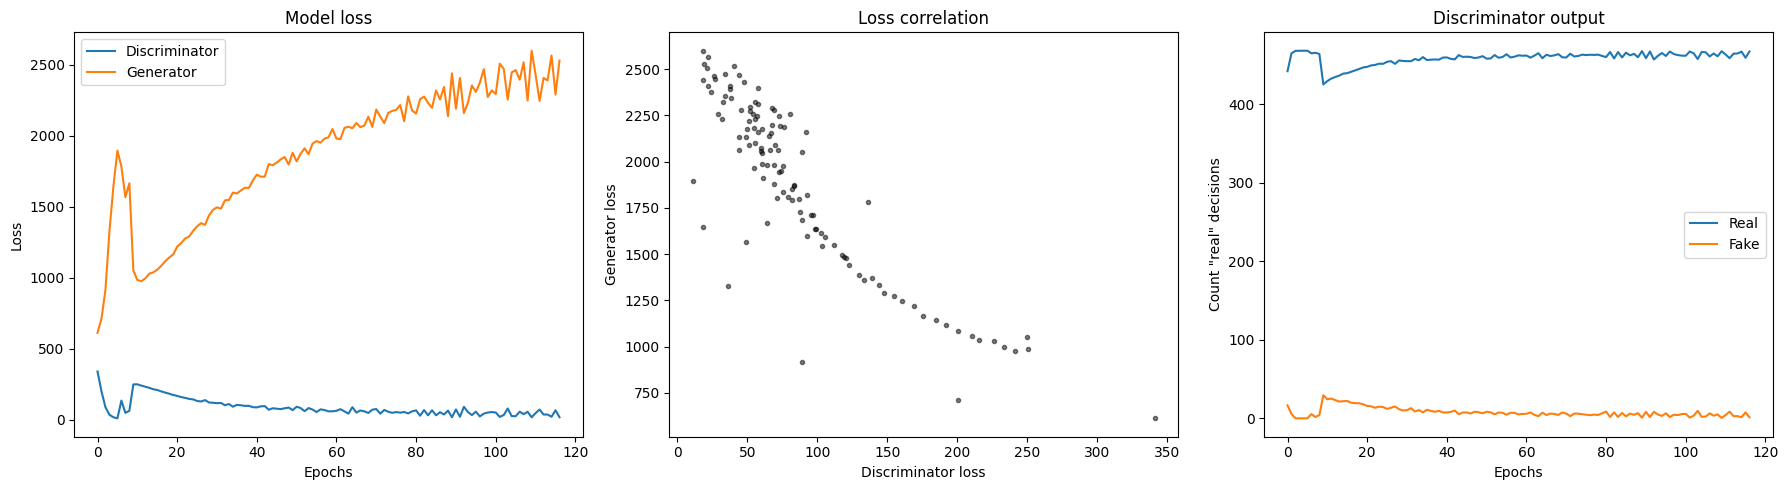

In [273]:
import numpy as np
losses_arr = np.array(losses)
dnet_decisions_arr = np.array(dnet_decisions)

fig,ax = plt.subplots(1,3,figsize=(18,5))

# Plotting losses
ax[0].plot(losses_arr[:,0])
ax[0].plot(losses_arr[:,1])
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discriminator','Generator'])

# Correlation
ax[1].plot(losses_arr[:,0], losses_arr[:,1], 'k.', alpha=.5)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')
ax[1].set_title('Loss correlation')

# Discriminator output probabilities
# Normalize by number of batches for better scale (optional)
ax[2].plot(dnet_decisions_arr[:,0])
ax[2].plot(dnet_decisions_arr[:,1])
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Count "real" decisions')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.tight_layout()
plt.show()

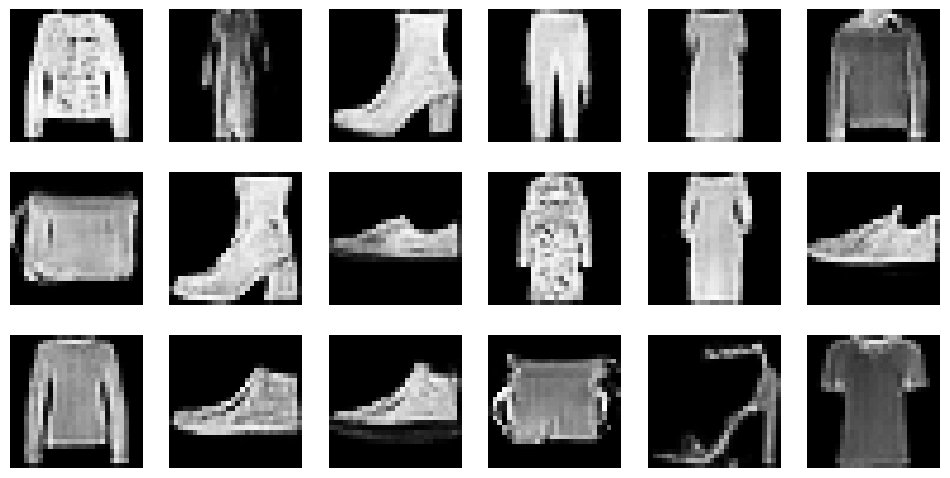

In [275]:
gnet.eval()
fake_data = gnet( torch.randn(bs,100,1,1).to(device) ).cpu()

# and visualize...
fig,axs = plt.subplots(3,6,figsize=(12,6))
for i,ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,].detach().squeeze(),cmap='grey',vmin=-1,vmax=1)
  ax.axis('off')

plt.show()